# 02 Preprocess

## 1. Load raw data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
TRAIN_DIR = BASE_DIR / "data" / "raw" / "MINDsmall_train"
VALID_DIR = BASE_DIR / "data" / "raw" / "MINDsmall_dev"

train_behaviors = pd.read_csv(TRAIN_DIR / "behaviors.tsv", sep="\t", header=None)
train_news = pd.read_csv(TRAIN_DIR / "news.tsv", sep="\t", header=None)

valid_behaviors = pd.read_csv(VALID_DIR / "behaviors.tsv", sep="\t", header=None)
valid_news = pd.read_csv(VALID_DIR / "news.tsv", sep="\t", header=None)

print("train_behaviors:", train_behaviors.shape)
print("train_news:", train_news.shape)
print("valid_behaviors:", valid_behaviors.shape)
print("valid_news:", valid_news.shape)

train_behaviors: (156965, 5)
train_news: (51282, 8)
valid_behaviors: (73152, 5)
valid_news: (42416, 8)


## 2. Add column names

In [31]:
behavior_cols = ["impression_id", "user_id", "time", "history", "impressions"]

train_behaviors.columns = behavior_cols
valid_behaviors.columns = behavior_cols

train_behaviors.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [32]:
news_cols = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

train_news.columns = news_cols
valid_news.columns = news_cols

train_news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [33]:
print("Train behaviors missing:")
print(train_behaviors.isnull().sum())
print("\nTrain news missing:")
print(train_news.isnull().sum())

Train behaviors missing:
impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64

Train news missing:
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64


## 3. Explore history and impressions

统计历史点击长度

In [34]:
def calc_history_len(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0
    return len(str(x).split(" "))

train_behaviors["history_len"] = train_behaviors["history"].apply(calc_history_len)
valid_behaviors["history_len"] = valid_behaviors["history"].apply(calc_history_len)

train_behaviors["history_len"].describe()

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64

画历史长度分布图

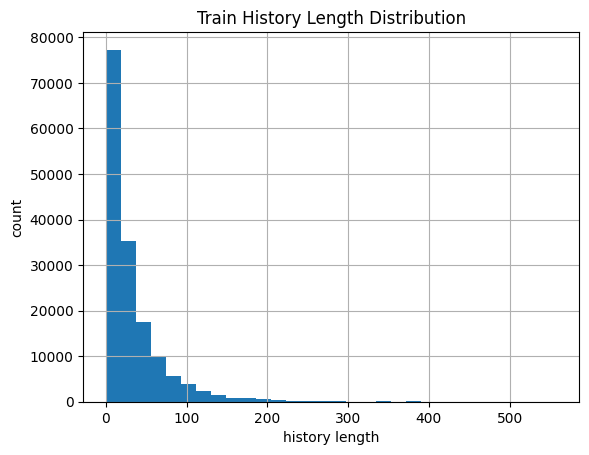

In [35]:
train_behaviors["history_len"].hist(bins=30)
plt.title("Train History Length Distribution")
plt.xlabel("history length")
plt.ylabel("count")
plt.show()

统计每次曝光里有多少候选新闻

In [36]:
def calc_impression_len(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0
    return len(str(x).split(" "))

train_behaviors["impression_len"] = train_behaviors["impressions"].apply(calc_impression_len)
valid_behaviors["impression_len"] = valid_behaviors["impressions"].apply(calc_impression_len)

train_behaviors["impression_len"].describe()

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_len, dtype: float64

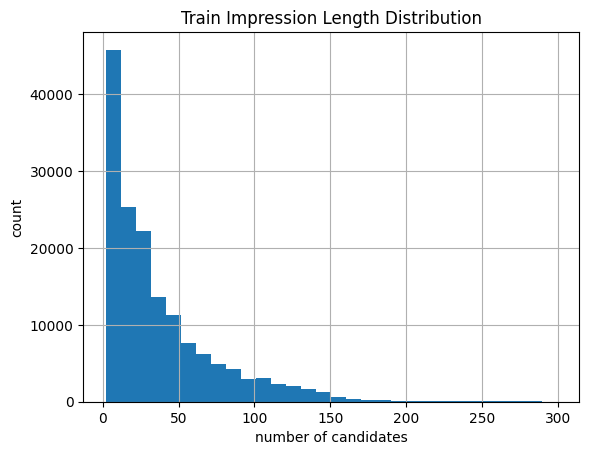

In [37]:
train_behaviors["impression_len"].hist(bins=30)
plt.title("Train Impression Length Distribution")
plt.xlabel("number of candidates")
plt.ylabel("count")
plt.show()

In [38]:
train_behaviors[["impression_id", "history", "impressions"]].sample(3, random_state=42)

,impression_id,history,impressions
78833,78834,N17157 N28081 N58641 N3926 N16290 N11894 N6185...,N60456-0 N19592-0 N35738-1 N3123-0 N12029-0 N3...
119940,119941,N1150 N53234 N45794 N11005 N55556,N50872-0 N19536-1
105873,105874,N58642 N65000 N871 N24778 N11101 N9798 N54827 ...,N5889-0 N63583-1 N56396-0 N37190-0 N5957-0 N73...


## 4. Expand impressions

将一行曝光记录拆成多行候选样本

In [39]:
def split_impressions(impressions_str):
    if pd.isna(impressions_str) or str(impressions_str).strip() == "":
        return []
    
    items = str(impressions_str).split(" ")
    result = []
    for item in items:
        news_id, label = item.rsplit("-", 1)
        result.append((news_id, int(label)))
    return result

# 测试
example = train_behaviors.loc[0, "impressions"]
print(example)
print(split_impressions(example)[:5])

N55689-1 N35729-0
[('N55689', 1), ('N35729', 0)]


In [40]:
def expand_behaviors(df, max_rows=None):
    rows = []
    
    if max_rows is not None:
        df = df.head(max_rows).copy()
    
    for _, row in df.iterrows():
        split_items = split_impressions(row["impressions"])
        for news_id, label in split_items:
            rows.append({
                "impression_id": row["impression_id"],
                "user_id": row["user_id"],
                "time": row["time"],
                "history": row["history"],
                "history_len": row.get("history_len", np.nan),
                "candidate_news_id": news_id,
                "label": label
            })
    
    return pd.DataFrame(rows)

# sample测试

In [17]:
train_expanded_sample = expand_behaviors(train_behaviors, max_rows=1000)
train_expanded_sample.head()

,impression_id,user_id,time,history,history_len,candidate_news_id,label
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N55689,1
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N35729,0
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N20678,0
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N39317,0
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N58114,0


In [18]:
train_expanded_sample["label"].value_counts(normalize=True)

label
0    0.961505
1    0.038495
Name: proportion, dtype: float64

In [19]:
ctr_sample = train_expanded_sample["label"].mean()
print("Sample CTR:", ctr_sample)

Sample CTR: 0.038494843737699756


## 5.Merge with news metadata

合并sample版本

In [20]:
train_sample_merged = train_expanded_sample.merge(
    train_news,
    left_on="candidate_news_id",
    right_on="news_id",
    how="left"
)

train_sample_merged.head()

,impression_id,user_id,time,history,history_len,candidate_news_id,label,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N55689,1,N55689,sports,football_nfl,"Charles Rogers, former Michigan State football...","Charles Rogers, the former Michigan State foot...",https://assets.msn.com/labs/mind/BBWAPO6.html,"[{""Label"": ""Charles Rogers (American football)...","[{""Label"": ""2003 NFL Draft"", ""Type"": ""U"", ""Wik..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N35729,0,N35729,news,newsus,Porsche launches into second story of New Jers...,The Porsche went airborne off a median in Toms...,https://assets.msn.com/labs/mind/BBWyjM9.html,"[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId...","[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId..."
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N20678,0,N20678,sports,more_sports,Bode Miller delivered his twin boys after midw...,Bode Miller added yet another impressive title...,https://assets.msn.com/labs/mind/BBWERWB.html,"[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida...","[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida..."
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N39317,0,N39317,news,newspolitics,"Senior Trump official embellished résumé, had ...",State Dept. official Mina Chang claimed to be ...,https://assets.msn.com/labs/mind/BBWEmIj.html,"[{""Label"": ""Donald Trump"", ""Type"": ""P"", ""Wikid...","[{""Label"": ""Harvard Business School"", ""Type"": ..."
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N58114,0,N58114,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,NaN,https://assets.msn.com/labs/mind/BBWEGnz.html,"[{""Label"": ""Ford Explorer"", ""Type"": ""V"", ""Wiki...",[]


In [21]:
train_sample_merged[["candidate_news_id", "news_id"]].isnull().sum()

candidate_news_id    0
news_id              0
dtype: int64

查看类别分布

In [22]:
train_sample_merged["category"].value_counts().head(10)

category
news             10393
lifestyle         4320
sports            3791
finance           3707
foodanddrink      2436
entertainment     2355
travel            2063
health            1892
autos             1827
music             1716
Name: count, dtype: int64

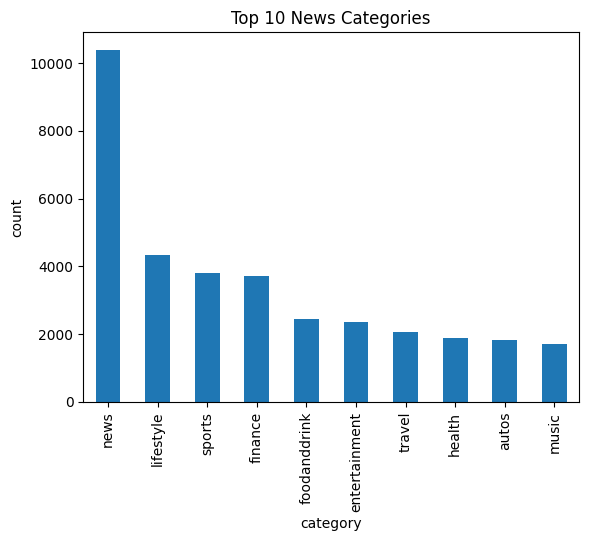

In [23]:
train_sample_merged["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 News Categories")
plt.xlabel("category")
plt.ylabel("count")
plt.show()

补充文本长度特征（标题长度和摘要长度）

In [24]:
train_sample_merged["title_len"] = train_sample_merged["title"].fillna("").apply(len)
train_sample_merged["abstract_len"] = train_sample_merged["abstract"].fillna("").apply(len)

train_sample_merged[["title_len", "abstract_len"]].describe()

,title_len,abstract_len
count,38109.000000,38109.000000
mean,65.589205,150.429531
std,20.873895,119.465680
min,11.000000,0.000000
25%,52.000000,74.000000
50%,63.000000,124.000000
75%,78.000000,180.000000
max,204.000000,1704.000000


# 正式处理train和valid

## 中等规模，试behaviors前20000行

In [25]:
train_expanded_20k = expand_behaviors(train_behaviors, max_rows=20000)
train_expanded_20k.shape

(737762, 7)

In [26]:
train_merged_20k = train_expanded_20k.merge(
    train_news,
    left_on="candidate_news_id",
    right_on="news_id",
    how="left"
)

train_merged_20k.shape

(737762, 15)

In [27]:
output_path = BASE_DIR / "data" / "processed" / "train_merged_20k.parquet"
train_merged_20k.to_parquet(output_path, index=False)
print("saved to:", output_path)

saved to: ../data/processed/train_merged_20k.parquet


In [28]:
valid_expanded_10k = expand_behaviors(valid_behaviors, max_rows=10000)

valid_merged_10k = valid_expanded_10k.merge(
    valid_news,
    left_on="candidate_news_id",
    right_on="news_id",
    how="left"
)

valid_output_path = BASE_DIR / "data" / "processed" / "valid_merged_10k.parquet"
valid_merged_10k.to_parquet(valid_output_path, index=False)

print("saved to:", valid_output_path)

saved to: ../data/processed/valid_merged_10k.parquet


In [29]:
check_df = pd.read_parquet(BASE_DIR / "data" / "processed" / "train_merged_20k.parquet")
check_df.head()

,impression_id,user_id,time,history,history_len,candidate_news_id,label,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N55689,1,N55689,sports,football_nfl,"Charles Rogers, former Michigan State football...","Charles Rogers, the former Michigan State foot...",https://assets.msn.com/labs/mind/BBWAPO6.html,"[{""Label"": ""Charles Rogers (American football)...","[{""Label"": ""2003 NFL Draft"", ""Type"": ""U"", ""Wik..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N35729,0,N35729,news,newsus,Porsche launches into second story of New Jers...,The Porsche went airborne off a median in Toms...,https://assets.msn.com/labs/mind/BBWyjM9.html,"[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId...","[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId..."
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N20678,0,N20678,sports,more_sports,Bode Miller delivered his twin boys after midw...,Bode Miller added yet another impressive title...,https://assets.msn.com/labs/mind/BBWERWB.html,"[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida...","[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida..."
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N39317,0,N39317,news,newspolitics,"Senior Trump official embellished résumé, had ...",State Dept. official Mina Chang claimed to be ...,https://assets.msn.com/labs/mind/BBWEmIj.html,"[{""Label"": ""Donald Trump"", ""Type"": ""P"", ""Wikid...","[{""Label"": ""Harvard Business School"", ""Type"": ..."
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N58114,0,N58114,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,None,https://assets.msn.com/labs/mind/BBWEGnz.html,"[{""Label"": ""Ford Explorer"", ""Type"": ""V"", ""Wiki...",[]


In [41]:
import sys
from pathlib import Path

sys.path.append(str((Path("..") / "src").resolve()))

from data.preprocess_utils import calc_history_len, split_impressions, expand_behaviors

print("import success")

import success
